In [1]:
from datasets import load_dataset

og_dataset = load_dataset("sentence-transformers/natural-questions", cache_dir="datasets", split="train")
dataset = og_dataset.shuffle(seed=22).select(range(1000))

In [2]:
from query_processing.missing import missing
from query_processing.missclicks import missclicks
from query_processing.moved import moved
from query_processing.process_query import process_query

configs = [
    {"mapping": missclicks, "ratios": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2]},
    {"mapping": missing, "ratios": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2]},
    {"mapping": moved, "ratios": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2]}
]

process_query(dataset, configs)

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
from completions.complete import complete
from completions.evaluate import evaluate
from completions.get_predictions import get_predictions

base_dir= "datasets/raw_datasets"
save_dir = "datasets/predictions"                 

await get_predictions(base_dir, save_dir, complete)

base_dir= "datasets/predictions"
save_dir = "datasets/evaluations"     

await get_predictions(base_dir, save_dir, evaluate)

Current: datasets/predictions/missclicks/ratio_0.03


In [ ]:
['id', 'query',
 'ground_truth', 'prediction',
 'judge_label', 'confidence',
 'reason', 'needs_review',
 'json_failed', 'raw_judge']

In [51]:
import os
from datasets import load_from_disk, Dataset, concatenate_datasets

base_dir= "datasets/evaluations"

all_datasets = []

for base_datasets in os.listdir(base_dir):
    base_datasets_path = f"{base_dir}/{base_datasets}"
    for dataset in os.listdir(base_datasets_path):
        base_dataset_path = f"{base_datasets_path}/{dataset}"
        
        loaded_dataset = load_from_disk(base_dataset_path)
        
        filtered_dataset = loaded_dataset.filter(lambda example: example["json_failed"]==False)
        
        filtered_dataset = filtered_dataset.add_column(
            name="function", column=[base_datasets for _ in range(len(filtered_dataset))])
        filtered_dataset = filtered_dataset.add_column(
            name="ratio", column=[dataset for _ in range(len(filtered_dataset))])

        all_datasets.append(filtered_dataset)
        
concatenated = concatenate_datasets(all_datasets)
concatenated.save_to_disk("datasets/concatenated")

Saving the dataset (0/1 shards):   0%|          | 0/14806 [00:00<?, ? examples/s]

OSError: [Errno 22] Invalid argument: 'D:/ml_projects/test/project/datasets/concatenated/data-00000-of-00001.arrow'

In [60]:
dataset = load_from_disk("datasets/concatenated")
df = dataset.to_pandas()

In [61]:
import matplotlib.pyplot as plt

In [62]:
df["ratio_value"] = (
    df["ratio"]
      .replace("baseline", "ratio_0")
      .str.replace("ratio_", "", regex=False)
      .astype(float)
)

In [63]:
df["correct"] = (df["judge_label"] == "correct").astype(int)

summary = (
    df.groupby(["function", "ratio_value"])
      .agg(
          n=("id", "size"),
          accuracy=("correct", "mean"),
          mean_confidence=("confidence", "mean"),
          std_confidence=("confidence", "std"),
      )
      .reset_index()
)

summary["accuracy"] *= 100
summary.round(2)

,function,ratio_value,n,accuracy,mean_confidence,std_confidence
0,baseline,0.00,931,48.76,93.27,18.99
1,missclicks,0.01,907,46.86,92.64,20.63
2,missclicks,0.05,935,42.14,91.53,21.69
3,missclicks,0.10,935,38.40,89.88,23.89
4,missclicks,0.15,926,29.81,85.59,28.69
5,missclicks,0.20,904,25.55,85.10,29.07
6,missing,0.01,942,47.88,93.96,17.30
7,missing,0.03,930,45.38,92.69,19.17
8,missing,0.05,938,42.75,91.52,21.89
9,missing,0.07,921,39.31,91.37,21.86


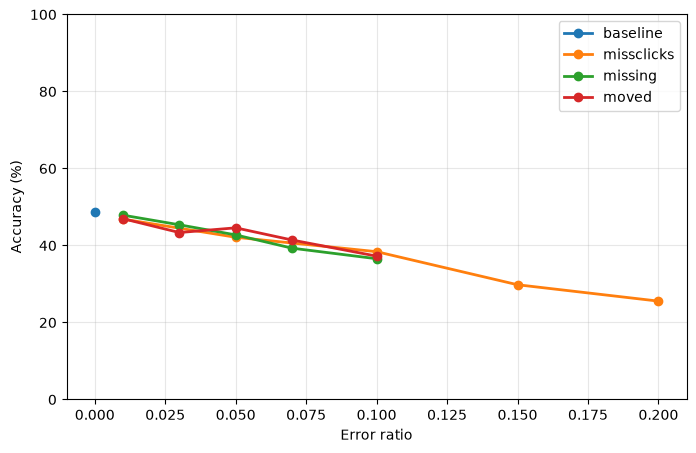

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name, g in summary.groupby("function"):
    plt.plot(
        g["ratio_value"],
        g["accuracy"],
        marker="o",
        linewidth=2,
        label=name,
    )

plt.xlabel("Error ratio")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.show()